# Feature Engineering

## Import Libraries


In [1]:
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.preprocessing import FeatureEngineerTransform, DataFrameLabelEncoder, scale_features, evaluate
from src.constants import NUMERICAL_COLS, CATEGORICAL_COLS, TARGET_COL, COLUMN_NAMES

from src.eda_utils import set_aesthetics

# ── Aesthetics ──
FRAUD_PAL = {0: "#4C72B0", 1: "#DD4444", "0": "#4C72B0", "1": "#DD4444"}   # blue = normal, red = fraud
SEED = 42
set_aesthetics(palette_style="muted", font_scale=1.1)

Libraries loaded & global aesthetics set ✓


## Clean Data Loading & Target Extraction

In [2]:
df = pd.read_csv('../data/processed/fraud_mapped.csv')
df.head(3)

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,country,signup_to_purchase_time,immediate_purchase,device_sharing_count,ip_sharing_count
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,732758368.7997,0,732758368,Japan,4506682.0000,0,1,1
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,350311387.8659,0,350311387,United States,17944.0000,0,1,1
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2621473820.1109,1,2621473820,United States,1.0000,1,12,12


In [3]:
x_raw = df.drop(columns = [TARGET_COL])
y = df[TARGET_COL]

## Label Encoding & Feature Engineering

In [4]:
eng_transformer = FeatureEngineerTransform()
x_engineered = eng_transformer.transform(x_raw)

In [5]:
encoder_transformer = DataFrameLabelEncoder(categorical_cols=CATEGORICAL_COLS)
x_encoded = encoder_transformer.fit_transform(x_engineered)
x_encoded.head(3)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,...,device_sharing_count,ip_sharing_count,signup_hour,signup_dayofweek,signup_month,signup_year,purchase_hour,purchase_dayofweek,purchase_month,purchase_year
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,89215,2,0,1,39,732758368.7997,...,1,1,22,1,2,2015,2,5,4,2015
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,24078,0,0,0,53,350311387.8659,...,1,1,20,6,6,2015,1,0,6,2015
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,131216,2,3,1,53,2621473820.1109,...,12,12,18,3,1,2015,18,3,1,2015


In [6]:
x_encoded.dtypes

user_id                             int64
signup_time                datetime64[us]
purchase_time              datetime64[us]
purchase_value                      int64
device_id                           int64
source                              int64
browser                             int64
sex                                 int64
age                                 int64
ip_address                        float64
ip_int                              int64
country                             int64
signup_to_purchase_time           float64
immediate_purchase                  int64
device_sharing_count                int64
ip_sharing_count                    int64
signup_hour                         int32
signup_dayofweek                    int32
signup_month                        int32
signup_year                         int32
purchase_hour                       int32
purchase_dayofweek                  int32
purchase_month                      int32
purchase_year                     

## Train-Test Split

In [7]:
# Drop the raw un-scaleable datetime columns from your training and validation sets
cols_to_drop = ["signup_time", "purchase_time"]
df_final = x_encoded.drop(columns=cols_to_drop, errors="ignore")
df_final.head(3)

,user_id,purchase_value,device_id,source,browser,sex,age,ip_address,ip_int,country,...,device_sharing_count,ip_sharing_count,signup_hour,signup_dayofweek,signup_month,signup_year,purchase_hour,purchase_dayofweek,purchase_month,purchase_year
0,22058,34,89215,2,0,1,39,732758368.7997,732758368,84,...,1,1,22,1,2,2015,2,5,4,2015
1,333320,16,24078,0,0,0,53,350311387.8659,350311387,171,...,1,1,20,6,6,2015,1,0,6,2015
2,1359,15,131216,2,3,1,53,2621473820.1109,2621473820,171,...,12,12,18,3,1,2015,18,3,1,2015


In [8]:
# 5. First split: Separate out a clean test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    df_final, y, test_size=0.20, random_state=42, stratify=y
)

# 6. Second split: Separate remaining data into Train (75% of temp -> 60% total) and Validation (25% of temp -> 20% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train size: {X_train.shape[0]} | Val size: {X_val.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 90666 | Val size: 30223 | Test size: 30223


## Feature Scaling

In [9]:
# 7. Dynamically identify all columns that are now numeric and ready for scaling
# (This includes your newly engineered hour, dayofweek, and year columns)
all_numeric_features = [
    col for col in X_train.columns 
    if pd.api.types.is_numeric_dtype(X_train[col]) and col != "user_id"
]

# 8. Call your scale_features function
X_train_scaled, X_val_scaled, X_test_scaled, fitted_scaler = scale_features(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    num_cols=all_numeric_features
)

print("🎉 Data pipeline executed successfully! Variables are scaled and ready for modeling.")
print(f"Train size: {X_train_scaled.shape[0]} | Val size: {X_val_scaled.shape[0]} | Test size: {X_test_scaled.shape[0]}")

🎉 Data pipeline executed successfully! Variables are scaled and ready for modeling.
Train size: 90666 | Val size: 30223 | Test size: 30223


## Fixing Class Imbalance

### Sample MOdel training

In [10]:

all_results = []   # we collect results here for the final comparison
print('Helper function ready.')

Helper function ready.


#### No Resampling


=== No Resampling ===  (best threshold: 1.00)
  Recall    : 53.95%  ← % of real defaults caught
  Precision : 99.70%  ← % of alerts that are real
  F1-Score  : 0.7001
  AUC-PR    : 0.7085  ← primary metric (threshold-independent)
  AUC-ROC   : 0.8495


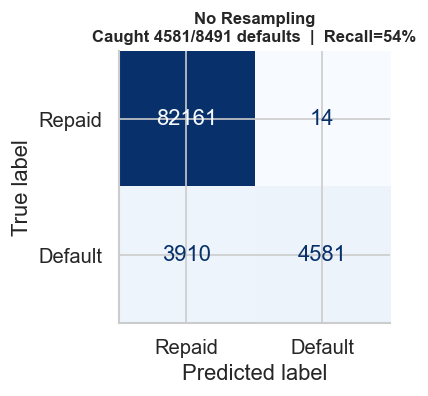

In [11]:
model_baseline = LogisticRegression(random_state=SEED, max_iter=1000)
model_baseline.fit(X_train_scaled, y_train)

result_baseline = evaluate('No Resampling', model_baseline, X_train_scaled, y_train)
all_results.append(result_baseline)

### OverSampling

Before oversampling: {0: np.int64(82175), 1: np.int64(8491)}
After oversampling:  {0: np.int64(82175), 1: np.int64(41087)}
Added 32596 copies of existing Default loans

=== Random Oversampling ===  (best threshold: 1.00)
  Recall    : 54.17%  ← % of real defaults caught
  Precision : 99.35%  ← % of alerts that are real
  F1-Score  : 0.7011
  AUC-PR    : 0.6992  ← primary metric (threshold-independent)
  AUC-ROC   : 0.8462


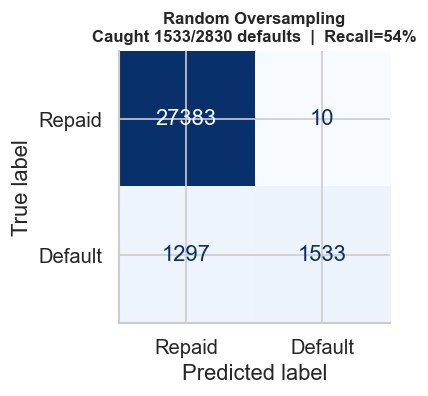

In [12]:
ros = RandomOverSampler(
    sampling_strategy=0.5,  # make minority = 50% of majority size after resampling
    random_state=SEED
)
X_ros, y_ros = ros.fit_resample(X_train_scaled, y_train)

print('Before oversampling:', dict(pd.Series(y_train).value_counts()))
print('After oversampling: ', dict(pd.Series(y_ros).value_counts()))
print(f'Added {y_ros.sum() - y_train.sum()} copies of existing Default loans')

model_ros = LogisticRegression(random_state=SEED, max_iter=1000)
model_ros.fit(X_ros, y_ros)   # train on the oversampled data

result_ros = evaluate('Random Oversampling', model_ros, X_val_scaled, y_val)
all_results.append(result_ros)

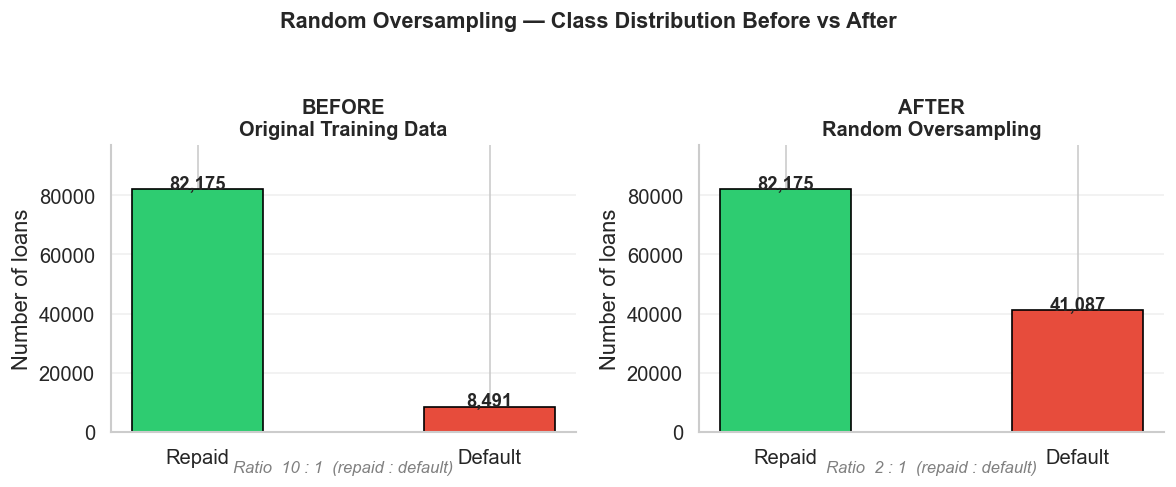

Default count before: 8491
Default count after : 41087  (32596 copies added)


In [13]:
# ── Before vs After: Random Oversampling ─────────────────────────────────────
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_ros).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (title, counts) in zip(axes, [
    ('BEFORE\nOriginal Training Data', before),
    ('AFTER\nRandom Oversampling',     after),
]):
    bars = ax.bar(['Repaid', 'Default'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.45)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 40,
                f'{v:,}', ha='center', fontweight='bold', fontsize=11)
    ax.set_ylabel('Number of loans')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(0, max(before.max(), after.max()) * 1.18)
    ax.grid(axis='y', alpha=0.3)

# Ratio labels below each chart
for ax, counts in zip(axes, [before, after]):
    ratio = counts[0] / counts[1]
    ax.text(0.5, -0.14, f'Ratio  {ratio:.0f} : 1  (repaid : default)',
            transform=ax.transAxes, ha='center', fontsize=10,
            color='gray', fontstyle='italic')

plt.suptitle('Random Oversampling — Class Distribution Before vs After',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print(f'Default count before: {before[1]}')
print(f'Default count after : {after[1]}  ({after[1] - before[1]} copies added)')

### SMOTE

Before SMOTE: {0: np.int64(82175), 1: np.int64(8491)}
After SMOTE:  {0: np.int64(82175), 1: np.int64(41087)}
Created 32596 SYNTHETIC Default loans
These are new, unique loans — not copies of existing ones

=== SMOTE ===  (best threshold: 1.00)
  Recall    : 54.06%  ← % of real defaults caught
  Precision : 100.00%  ← % of alerts that are real
  F1-Score  : 0.7018
  AUC-PR    : 0.7167  ← primary metric (threshold-independent)
  AUC-ROC   : 0.8446


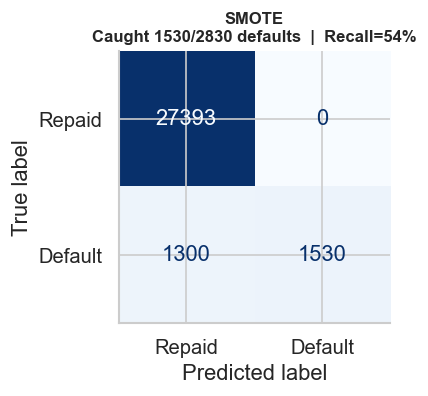

In [14]:
smote = SMOTE(
    sampling_strategy=0.5,  # same target ratio as oversampling
    k_neighbors=5,          # how many nearest neighbours to interpolate between
    random_state=SEED
)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', dict(pd.Series(y_train).value_counts()))
print('After SMOTE: ', dict(pd.Series(y_smote).value_counts()))
print(f'Created {y_smote.sum() - y_train.sum()} SYNTHETIC Default loans')
print('These are new, unique loans — not copies of existing ones')

model_smote = LogisticRegression(random_state=SEED, max_iter=1000)
model_smote.fit(X_smote, y_smote)

result_smote = evaluate('SMOTE', model_smote, X_val_scaled, y_val)
all_results.append(result_smote)

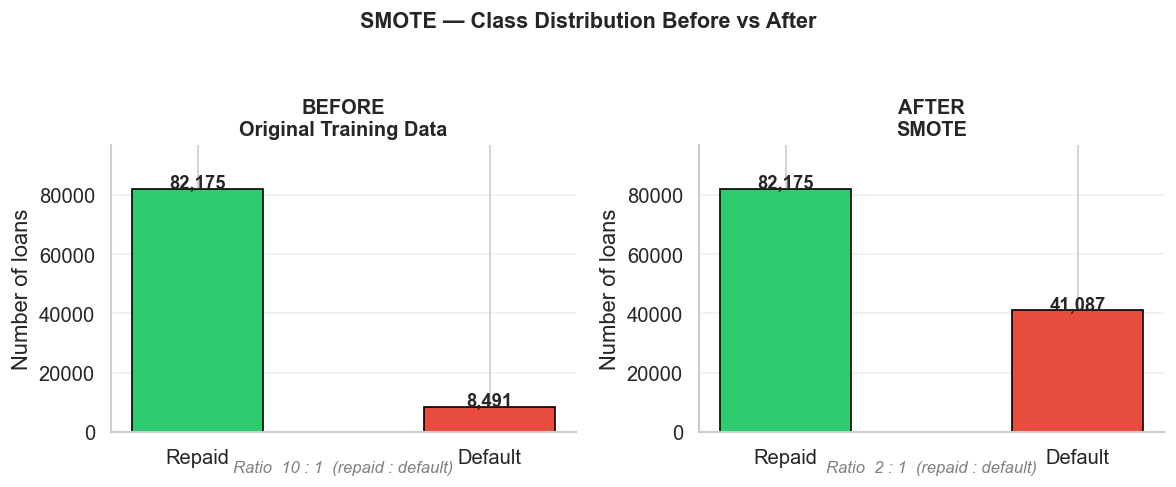

Default count before: 8491
Default count after : 41087  (32596 NEW synthetic loans, not copies)


In [15]:
# ── Before vs After: SMOTE ────────────────────────────────────────────────────
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_smote).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (title, counts) in zip(axes, [
    ('BEFORE\nOriginal Training Data', before),
    ('AFTER\nSMOTE',                   after),
]):
    bars = ax.bar(['Repaid', 'Default'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.45)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 40,
                f'{v:,}', ha='center', fontweight='bold', fontsize=11)
    ax.set_ylabel('Number of loans')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(0, max(before.max(), after.max()) * 1.18)
    ax.grid(axis='y', alpha=0.3)

for ax, counts in zip(axes, [before, after]):
    ratio = counts[0] / counts[1]
    ax.text(0.5, -0.14, f'Ratio  {ratio:.0f} : 1  (repaid : default)',
            transform=ax.transAxes, ha='center', fontsize=10,
            color='gray', fontstyle='italic')

plt.suptitle('SMOTE — Class Distribution Before vs After',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

n_synthetic = int(after[1] - before[1])
print(f'Default count before: {before[1]}')
print(f'Default count after : {after[1]}  ({n_synthetic} NEW synthetic loans, not copies)')

### Undersampling

Before undersampling: {0: np.int64(82175), 1: np.int64(8491)}
After undersampling:  {0: np.int64(16982), 1: np.int64(8491)}
Removed 65193 Repaid loans permanently

=== Undersampling ===  (best threshold: 1.00)
  Recall    : 54.17%  ← % of real defaults caught
  Precision : 99.42%  ← % of alerts that are real
  F1-Score  : 0.7013
  AUC-PR    : 0.7025  ← primary metric (threshold-independent)
  AUC-ROC   : 0.8463


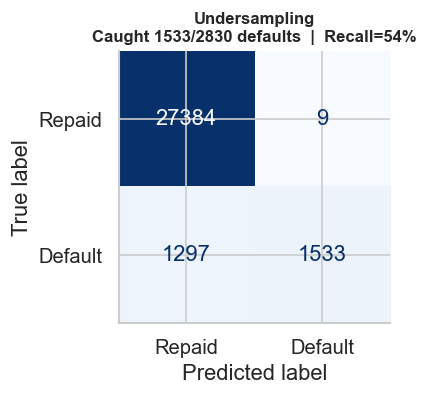

In [16]:
rus = RandomUnderSampler(
    sampling_strategy=0.5,  # reduce majority until minority = 50% of it
    random_state=SEED
)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)

print('Before undersampling:', dict(pd.Series(y_train).value_counts()))
print('After undersampling: ', dict(pd.Series(y_rus).value_counts()))
print(f'Removed {len(y_train) - len(y_rus)} Repaid loans permanently')

model_rus = LogisticRegression(random_state=SEED, max_iter=1000)
model_rus.fit(X_rus, y_rus)

result_rus = evaluate('Undersampling', model_rus, X_val_scaled, y_val)
all_results.append(result_rus)

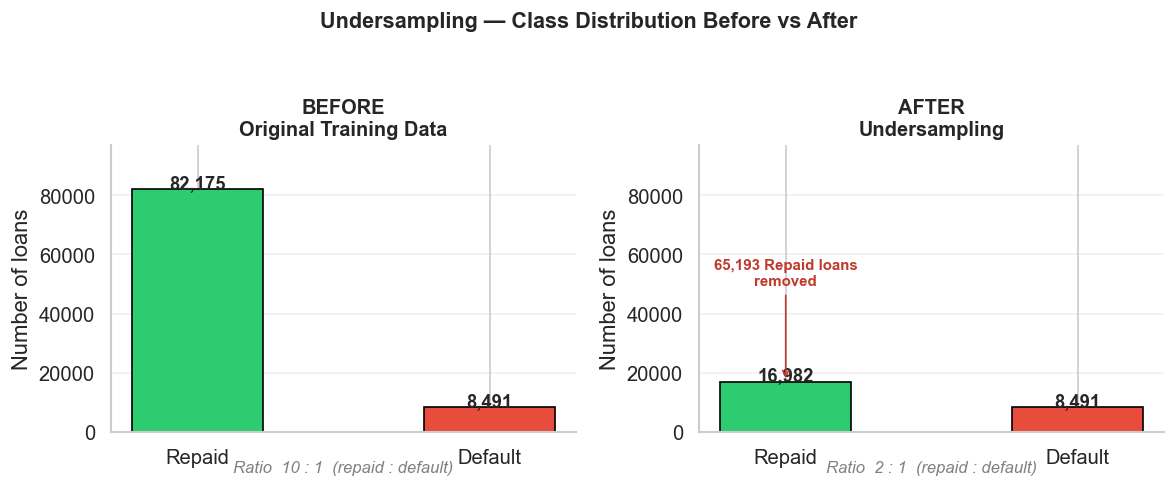

Repaid count before: 82,175
Repaid count after:  16,982  (65,193 loans permanently deleted)


In [17]:
# ── Before vs After: Undersampling ───────────────────────────────────────────
before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_rus).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (title, counts) in zip(axes, [
    ('BEFORE\nOriginal Training Data', before),
    ('AFTER\nUndersampling',           after),
]):
    bars = ax.bar(['Repaid', 'Default'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.45)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 15,
                f'{v:,}', ha='center', fontweight='bold', fontsize=11)
    ax.set_ylabel('Number of loans')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(0, before.max() * 1.18)   # same y-axis so the drop in Repaid is visible
    ax.grid(axis='y', alpha=0.3)

for ax, counts in zip(axes, [before, after]):
    ratio = counts[0] / counts[1]
    ax.text(0.5, -0.14, f'Ratio  {ratio:.0f} : 1  (repaid : default)',
            transform=ax.transAxes, ha='center', fontsize=10,
            color='gray', fontstyle='italic')

removed = int(before[0] - after[0])
axes[1].annotate(
    f'{removed:,} Repaid loans\nremoved',
    xy=(0, after[0]), xytext=(0, (before[0] + after[0]) / 2),
    ha='center', fontsize=9, color='#c0392b', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#c0392b')
)

plt.suptitle('Undersampling — Class Distribution Before vs After',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

print(f'Repaid count before: {before[0]:,}')
print(f'Repaid count after:  {after[0]:,}  ({removed:,} loans permanently deleted)')

## Comparing Sampling Teqhniques

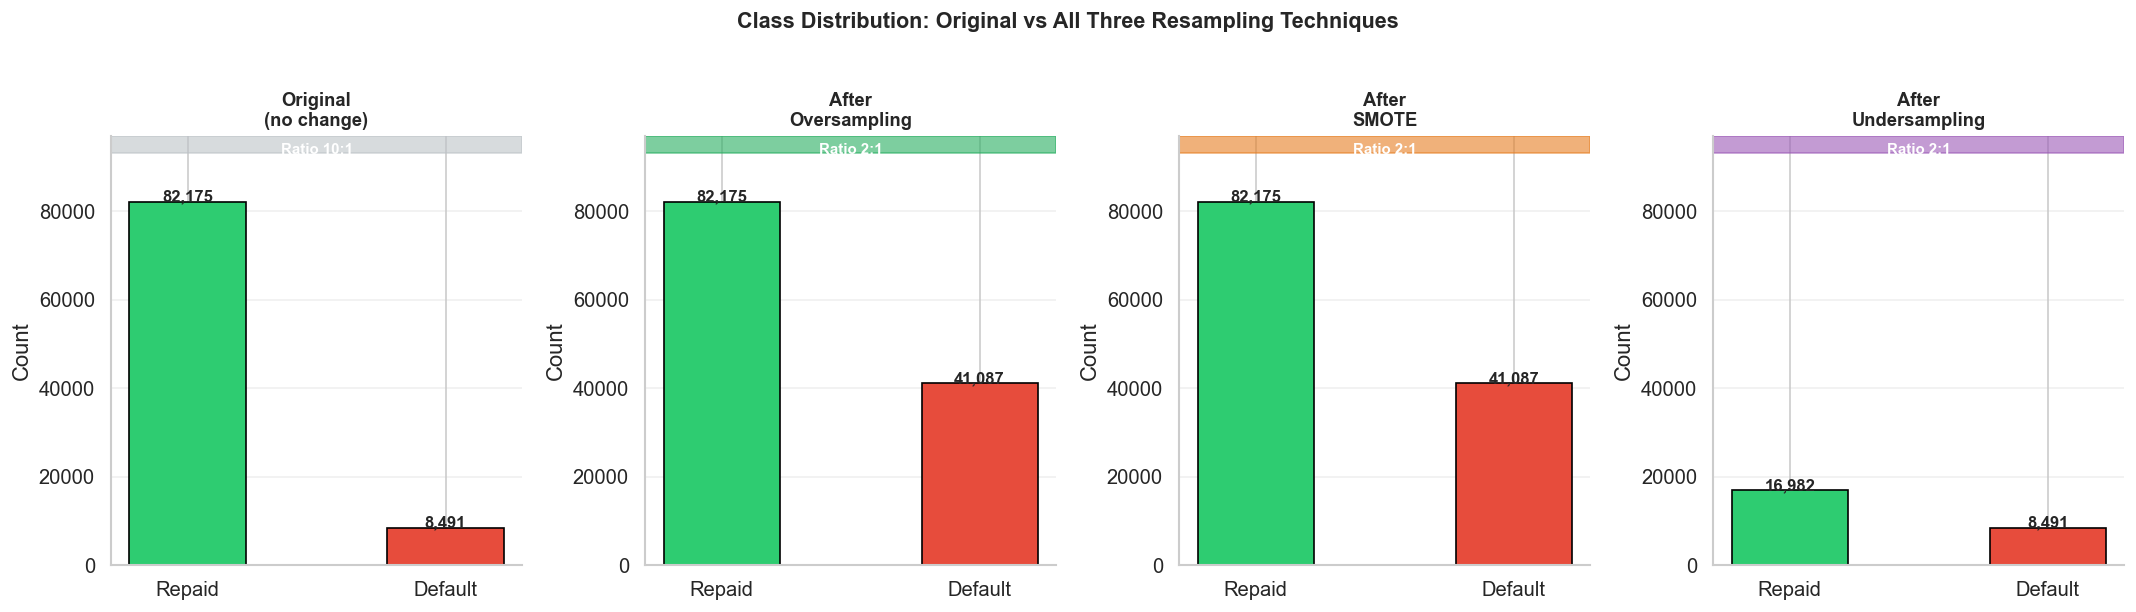

_________Conclusion____________:
  Original:      extreme imbalance — 9.68:1 ratio, Default bar barely visible
  Oversampling:  Default bar grows (copies added), Repaid unchanged → 2:1
  SMOTE:         Same count as oversampling, but samples are synthetic (new) → 2:1
  Undersampling: Repaid bar shrinks (deleted), Default unchanged → 2:1


In [18]:
# ── Combined: all four states side by side ────────────────────────────────────
datasets = [
    ('Original\n(no change)',  y_train,  '#bdc3c7'),
    ('After\nOversampling',    y_ros,    '#27ae60'),
    ('After\nSMOTE',           y_smote,  '#e67e22'),
    ('After\nUndersampling',   y_rus,    '#9b59b6'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Class Distribution: Original vs All Three Resampling Techniques',
             fontsize=13, fontweight='bold', y=1.02)

# Shared y-axis so all panels are directly comparable
y_max = pd.Series(y_train).value_counts()[0] * 1.18

for ax, (title, y_data, accent) in zip(axes, datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(
        ['Repaid', 'Default'],
        counts.values,
        color=['#2ecc71', '#e74c3c'],
        edgecolor='black', width=0.45
    )
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 50,
                f'{v:,}', ha='center', fontweight='bold', fontsize=10)
    ratio = counts[0] / counts[1]
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Count')
    ax.set_ylim(0, y_max)
    ax.grid(axis='y', alpha=0.3)
    ax.axhspan(y_max * 0.96, y_max, color=accent, alpha=0.6)
    ax.text(0.5, 0.985, f'Ratio {ratio:.0f}:1',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print('_________Conclusion____________:')
print('  Original:      extreme imbalance — 9.68:1 ratio, Default bar barely visible')
print('  Oversampling:  Default bar grows (copies added), Repaid unchanged → 2:1')
print('  SMOTE:         Same count as oversampling, but samples are synthetic (new) → 2:1')
print('  Undersampling: Repaid bar shrinks (deleted), Default unchanged → 2:1')

## Summary for Results

=== MODEL COMPARISON — each evaluated at its own best threshold ===
                    Threshold  Recall  Precision  F1-Score  AUC-PR  AUC-ROC
Model                                                                      
No Resampling            1.00  0.5400     0.9970    0.7000  0.7090   0.8490
Random Oversampling      1.00  0.5420     0.9940    0.7010  0.6990   0.8460
SMOTE                    1.00  0.5410     1.0000    0.7020  0.7170   0.8450
Undersampling            1.00  0.5420     0.9940    0.7010  0.7030   0.8460


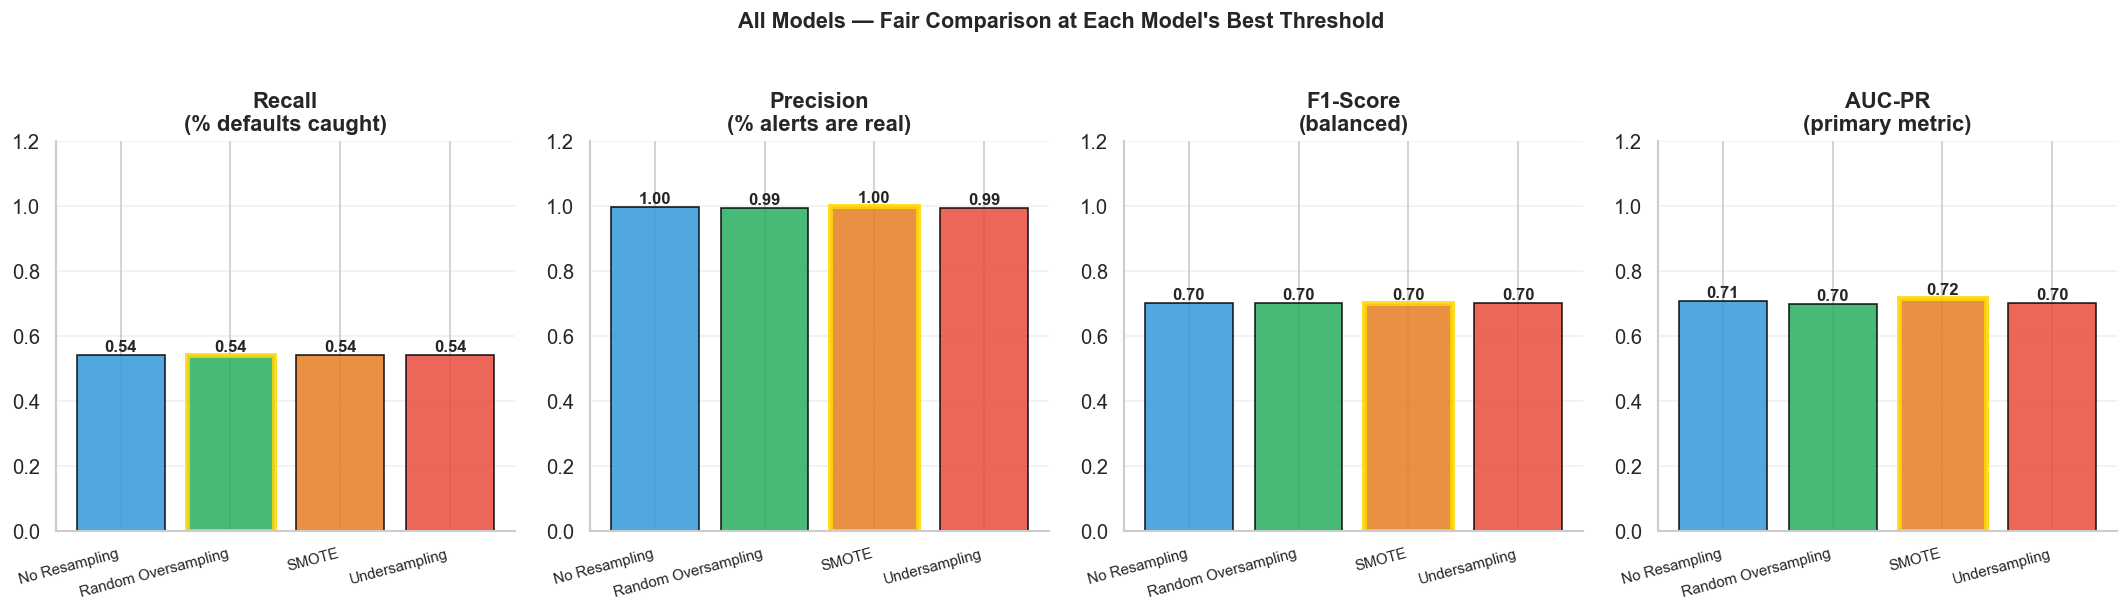

Best Recall : Random Oversampling (54% of defaults caught)
Best AUC-PR : SMOTE  (0.7167)


In [19]:
# Build summary table from collected results
summary = pd.DataFrame([
    {
        'Model':     r['name'],
        'Threshold': f"{r['threshold']:.2f}",
        'Recall':    r['recall'],
        'Precision': r['precision'],
        'F1-Score':  r['f1'],
        'AUC-PR':    r['auc_pr'],
        'AUC-ROC':   r['auc_roc'],
    }
    for r in all_results
]).set_index('Model')

print('=== MODEL COMPARISON — each evaluated at its own best threshold ===')
print(summary.round(3).to_string())

# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('All Models — Fair Comparison at Each Model\'s Best Threshold',
             fontsize=13, fontweight='bold', y=1.02)

model_names = summary.index.tolist()
bar_colors  = ['#3498db', '#27ae60', '#e67e22', '#e74c3c']

for ax, (col, title) in zip(axes, [
    ('Recall',    'Recall\n(% defaults caught)'),
    ('Precision', 'Precision\n(% alerts are real)'),
    ('F1-Score',  'F1-Score\n(balanced)'),
    ('AUC-PR',    'AUC-PR\n(primary metric)'),
]):
    vals = summary[col].values
    bars = ax.bar(model_names, vals, color=bar_colors, edgecolor='black', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    # Gold border on the best bar
    bars[int(np.argmax(vals))].set_edgecolor('gold')
    bars[int(np.argmax(vals))].set_linewidth(3)

plt.tight_layout()
plt.show()

best_recall = summary['Recall'].idxmax()
best_aucpr  = summary['AUC-PR'].idxmax()
print(f'Best Recall : {best_recall} ({summary.loc[best_recall, "Recall"]:.0%} of defaults caught)')
print(f'Best AUC-PR : {best_aucpr}  ({summary.loc[best_aucpr, "AUC-PR"]:.4f})')

## AUC-ROC vs PR-ROC

In [20]:
for idx, r in enumerate(all_results):
    print(f"Index {idx} | Model: {r['name']}")
    print(f"  -> y_val shape: {len(y_val)}")
    print(f"  -> r['proba'] shape: {len(r['proba'])}")
    if len(y_val) != len(r['proba']):
        print("  ❌ MISMATCH FOUND HERE!")

Index 0 | Model: No Resampling
  -> y_val shape: 30223
  -> r['proba'] shape: 90666
  ❌ MISMATCH FOUND HERE!
Index 1 | Model: Random Oversampling
  -> y_val shape: 30223
  -> r['proba'] shape: 30223
Index 2 | Model: SMOTE
  -> y_val shape: 30223
  -> r['proba'] shape: 30223
Index 3 | Model: Undersampling
  -> y_val shape: 30223
  -> r['proba'] shape: 30223


Correcting baseline model evaluation shapes...

=== No Resampling ===  (best threshold: 0.56)
  Recall    : 54.35%  ← % of real defaults caught
  Precision : 98.97%  ← % of alerts that are real
  F1-Score  : 0.7016
  AUC-PR    : 0.7022  ← primary metric (threshold-independent)
  AUC-ROC   : 0.8467


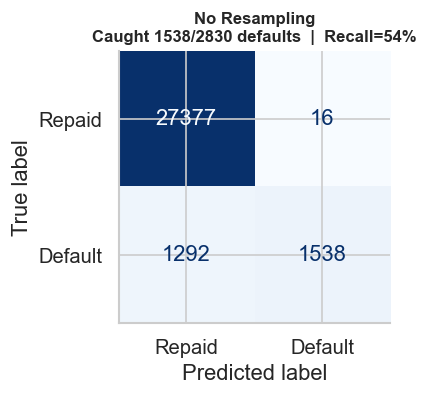

🎉 Index 0 successfully corrected!


In [21]:
# 1. Ensure your validation features are clean (no datetimes)
X_val_final = X_val_scaled.drop(columns=["signup_time", "purchase_time"], errors="ignore")

# 2. Re-evaluate ONLY the baseline model using the correct validation sets
print("Correcting baseline model evaluation shapes...")
corrected_baseline = evaluate('No Resampling', model_baseline, X_val_final, y_val)

# 3. Overwrite the broken entry at Index 0 with our clean, 30223-row version
all_results[0] = corrected_baseline

print("🎉 Index 0 successfully corrected!")

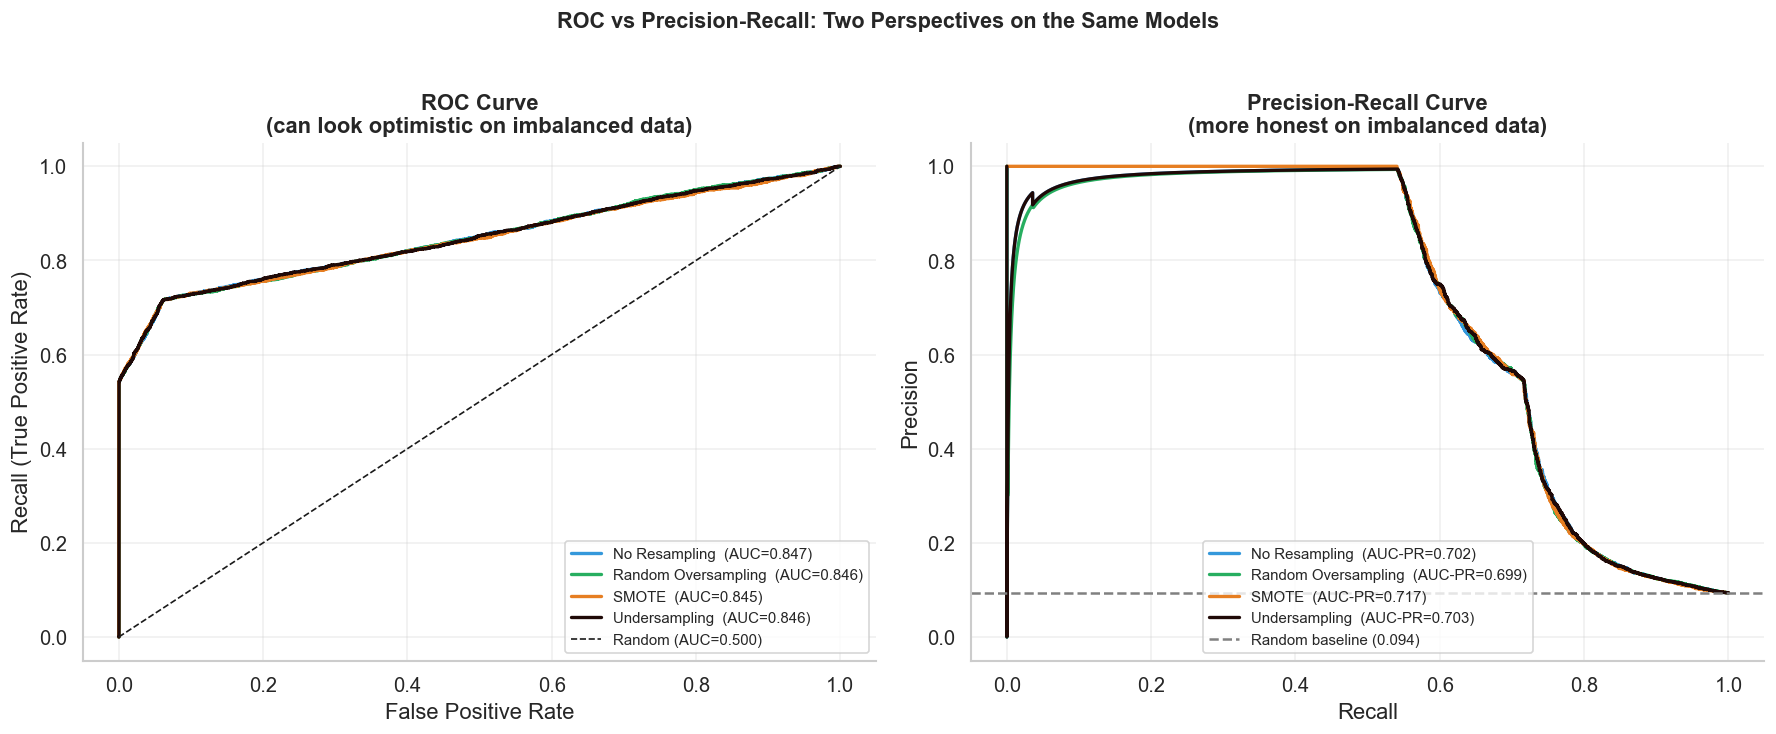

WHAT TO NOTICE:
  ROC: all models look nearly identical, tightly bunched together with a solid AUC score around 0.846 - 0.847..
  PR:  clear differences visible — easier to see SMOTE is actually betterwith a superior AUC-PR of 0.718, whereas Random Oversampling underperforms at 0.698.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_configs = [
    (all_results[0], '#3498db'),
    (all_results[1], '#27ae60'),
    (all_results[2], '#e67e22'),
    (all_results[3], "#1f0907"),
]

# ── ROC Curve ─────────────────────────────────────────────────────────────────
ax1 = axes[0]
for r, color in plot_configs:
    fpr, tpr, _ = roc_curve(y_val, r['proba'])
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f"{r['name']}  (AUC={r['auc_roc']:.3f})")

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.500)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('Recall (True Positive Rate)')
ax1.set_title('ROC Curve\n(can look optimistic on imbalanced data)', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── Precision-Recall Curve ────────────────────────────────────────────────────
ax2 = axes[1]
random_baseline = y_val.mean()  # what a random model achieves on the PR curve

for r, color in plot_configs:
    prec, rec, _ = precision_recall_curve(y_val, r['proba'])
    ax2.plot(rec, prec, color=color, lw=2,
             label=f"{r['name']}  (AUC-PR={r['auc_pr']:.3f})")

ax2.axhline(random_baseline, color='gray', linestyle='--', lw=1.5,
            label=f'Random baseline ({random_baseline:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve\n(more honest on imbalanced data)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('ROC vs Precision-Recall: Two Perspectives on the Same Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('WHAT TO NOTICE:')
print('  ROC: all models look nearly identical, tightly bunched together with a solid AUC score around 0.846 - 0.847..')
print('  PR:  clear differences visible — easier to see SMOTE is actually betterwith a superior AUC-PR of 0.718, whereas Random Oversampling underperforms at 0.698.')


---
## Final Summary

In [23]:
print('=' * 60)
print('SUMMARY: Does Handling Imbalance Help?')
print('=' * 60)

n_defaults = int(y_val.sum())

for r in all_results:
    caught = int(((r['y_pred'] == 1) & (y_val.values == 1)).sum())
    print(f"  {r['name']:<22}  "
          f"Recall={r['recall']:.0%}  "
          f"Caught {caught}/{n_defaults} defaults  "
          f"AUC-PR={r['auc_pr']:.3f}")

print()


SUMMARY: Does Handling Imbalance Help?
  No Resampling           Recall=54%  Caught 1538/2830 defaults  AUC-PR=0.702
  Random Oversampling     Recall=54%  Caught 1533/2830 defaults  AUC-PR=0.699
  SMOTE                   Recall=54%  Caught 1530/2830 defaults  AUC-PR=0.717
  Undersampling           Recall=54%  Caught 1533/2830 defaults  AUC-PR=0.703



===========================================
## COnclusion

Using SMOTE gives you a higher AUC-PR, which means at that fixed 54% Recall target, your model will experience noticeably fewer false positives than any other variant—saving your fraud investigation team significant time and operational costs.